# 4. Evaluation Metrics for Classification

Dataset: https://www.kaggle.com/blastchar/telco-customer-churn

https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
!wget $data -O churn-data.csv

--2026-06-05 19:40:12--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8000::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘churn-data.csv’

churn-data.csv      100%[===================>] 954.59K  --.-KB/s    in 0.04s   

2026-06-05 19:40:12 (26.3 MB/s) - ‘churn-data.csv’ saved [977501/977501]



In [4]:
df = pd.read_csv('churn-data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression 

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [7]:
df.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [8]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']


In [9]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [10]:
np.unique(y_train)

array([0, 1])

In [11]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear', random_state=1)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [12]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8055358410220014)

In [13]:
y_proba = model.predict_proba(X_val)[:, 1]
y_proba 

array([0.00735888, 0.2097209 , 0.2207079 , ..., 0.14887969, 0.78483927,
       0.81058075], shape=(1409,))

# 4.2 Accuracy and dummy model

In [14]:
len(y_val)

1409

In [15]:
(y_val == churn_decision).sum()

np.int64(1135)

In [16]:
1135 / 1409

0.8055358410220014

In [17]:
from sklearn.metrics import accuracy_score 

In [18]:
accuracy_score(y_val, y_pred >= 0.5)

0.8055358410220014

In [19]:
thresholds = np.linspace(0, 1, 21)
scores = []
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.274
0.05 0.508
0.10 0.605
0.15 0.664
0.20 0.705
0.25 0.738
0.30 0.759
0.35 0.767
0.40 0.781
0.45 0.793
0.50 0.806
0.55 0.804
0.60 0.800
0.65 0.787
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


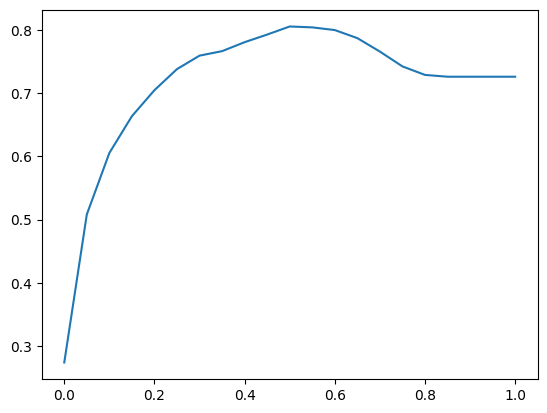

In [20]:
ptl.plot(thresholds, scores)

# 4.3 Confusion table

A confusion table compares the model's predicted classes with the actual classes.

For binary classification:

- `1` = positive class, for example churn
- `0` = negative class, for example not churn

The model first outputs probabilities. We use a threshold to convert those probabilities into class predictions.

For example:

```python
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)
```

This means:

- If `y_pred >= 0.5`, predict churn.
- If `y_pred < 0.5`, predict not churn.

## Four Parts of the Confusion Table

- **True Positive (TP)**: predicted churn and the customer actually churned.
- **True Negative (TN)**: predicted not churn and the customer actually did not churn.
- **False Positive (FP)**: predicted churn but the customer did not churn.
- **False Negative (FN)**: predicted not churn but the customer actually churned.

## Confusion Matrix Layout

The confusion matrix is arranged as:

```text
[[TN, FP],
 [FN, TP]]
```

In this example:

```text
[[923, 100],
 [174, 212]]
```

This means:

- `923` customers were correctly predicted as not churn.
- `100` customers were incorrectly predicted as churn.
- `174` customers were incorrectly predicted as not churn, but they actually churned.
- `212` customers were correctly predicted as churn.

## Percentage Version

As percentages:

```text
[[0.66, 0.07],
 [0.12, 0.15]]
```

So:

- `66%` are true negatives.
- `7%` are false positives.
- `12%` are false negatives.
- `15%` are true positives.

## Key Idea

The model is good at identifying many customers who did not churn, but it still misses some customers who actually churned.

In churn prediction, false negatives are important because they represent customers who actually churned but were predicted as not churn.

In [21]:
from collections import Counter
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [22]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [23]:
t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

In [24]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [26]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix 

array([[923, 100],
       [174, 212]])

In [27]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.66, 0.07],
       [0.12, 0.15]])

## 4.4 Precision and Recall

Precision and recall are classification metrics used to evaluate how well the model predicts the positive class.

In this churn example:

- `1` = churn
- `0` = not churn

From the confusion matrix:

```text
[[TN, FP],
 [FN, TP]]

[[923, 100],
 [174, 212]]
```

So:

- `TP = 212`
- `FP = 100`
- `FN = 174`
- `TN = 923`

## Precision

Precision measures how many of the predicted churn customers actually churned.

$$
Precision = \frac{TP}{TP + FP}
$$

Using the values:

$$
Precision = \frac{212}{212 + 100}
$$

$$
Precision = 0.679
$$

So the precision is about **67.9%**.

This means that when the model predicts churn, it is correct about **68% of the time**.

## Recall

Recall measures how many of the actual churn customers the model successfully found.

$$
Recall = \frac{TP}{TP + FN}
$$

Using the values:

$$
Recall = \frac{212}{212 + 174}
$$

$$
Recall = 0.549
$$

So the recall is about **54.9%**.

This means the model catches about **55% of the customers who actually churned**.

## Key Difference

Precision answers:

> Of all customers predicted as churn, how many actually churned?

Recall answers:

> Of all customers who actually churned, how many did the model find?

## Key Idea

High precision means the model's churn predictions are reliable.

High recall means the model catches more of the actual churn customers.

In churn prediction, recall is often important because false negatives mean customers actually churned but the model failed to identify them.

In [28]:
# Precision: the fraction of the number of people that are actually turning over the sum of people that we predictd 
# to be churning and the ones we predicted to be churning but did not churn 
p = tp / (tp + fp)
p

np.float64(0.6794871794871795)

In [29]:
# Recall fraction of churning users that we predicted positivaly 
r = tp / (tp + fn)
r 

np.float64(0.5492227979274611)

# ROC Curves 

In [33]:
tpr = tp / (tp + fn)
tpr

np.float64(0.5492227979274611)

In [34]:
r 

np.float64(0.5492227979274611)

In [35]:
fpr = fp / (fp + tn)
fpr

np.float64(0.09775171065493646)

In [57]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))
    

In [58]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [59]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,367,537,19,486,0.950777,0.524927
20,0.2,337,367,49,656,0.873057,0.358749
30,0.3,292,245,94,778,0.756477,0.239492
40,0.4,252,175,134,848,0.652850,0.171065
50,0.5,212,100,174,923,0.549223,0.097752
60,0.6,155,51,231,972,0.401554,0.049853
70,0.7,69,13,317,1010,0.178756,0.012708
80,0.8,4,0,382,1023,0.010363,0.000000
90,0.9,0,0,386,1023,0.000000,0.000000


In [46]:
scores_df['tpr'] = scores_df.tp /(scores_df.tp + scores_df.fn)
scores_df['fpr'] = scores_df.fp /(scores_df.fp + scores_df.tn)

In [47]:
scores_df[::10]

,t,tp,tn,fp,fn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,0.000000
10,0.1,367,537,19,486,0.430246,0.034173
20,0.2,337,367,49,656,0.339376,0.117788
30,0.3,292,245,94,778,0.272897,0.277286
40,0.4,252,175,134,848,0.229091,0.433657
50,0.5,212,100,174,923,0.186784,0.635036
60,0.6,155,51,231,972,0.137533,0.819149
70,0.7,69,13,317,1010,0.063948,0.960606
80,0.8,4,0,382,1023,0.003895,1.000000
90,0.9,0,0,386,1023,0.000000,1.000000


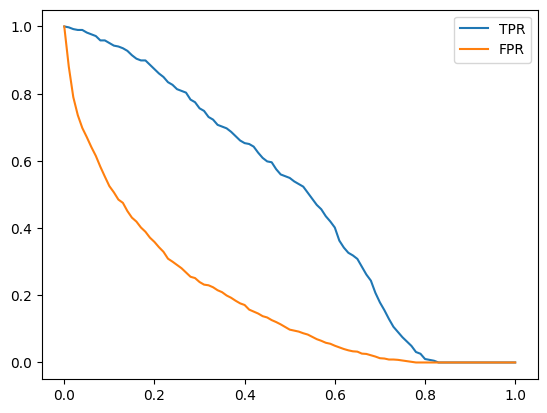

In [62]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

In [66]:
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [67]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5060326472675657)

In [68]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
    
    return df_scores

In [69]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

In [70]:
df_rand[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,350,917,36,106,0.906736,0.896383
20,0.2,305,801,81,222,0.790155,0.782991
30,0.3,270,703,116,320,0.699482,0.687195
40,0.4,241,614,145,409,0.624352,0.600196
50,0.5,194,504,192,519,0.502591,0.492669
60,0.6,148,417,238,606,0.383420,0.407625
70,0.7,105,315,281,708,0.272021,0.307918
80,0.8,70,204,316,819,0.181347,0.199413
90,0.9,36,99,350,924,0.093264,0.096774


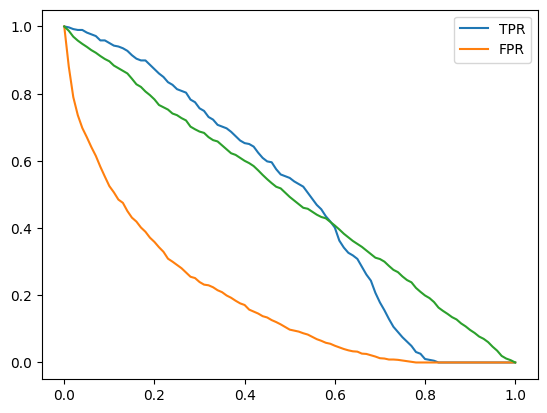

In [71]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.plot(df_rand.threshold, df_rand['fpr'])

plt.legend()

In [72]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [73]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])

In [74]:
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [75]:
y_ideal_pred = np.linspace(0, 1, len(y_val))


In [76]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [77]:
((y_ideal_pred >= 0.7260) == y_ideal ).mean()

np.float64(1.0)

In [78]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


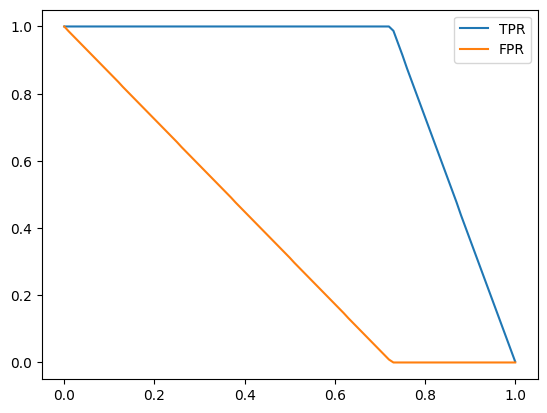

In [79]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

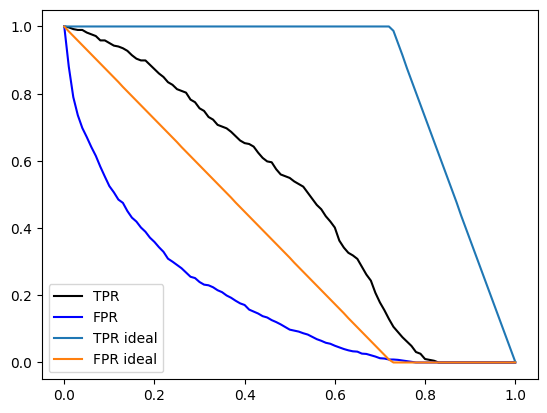

In [80]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR', color='black')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR', color='blue')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR ideal')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR ideal')

# plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR random', color='grey')
# plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR random', color='grey')

plt.legend()

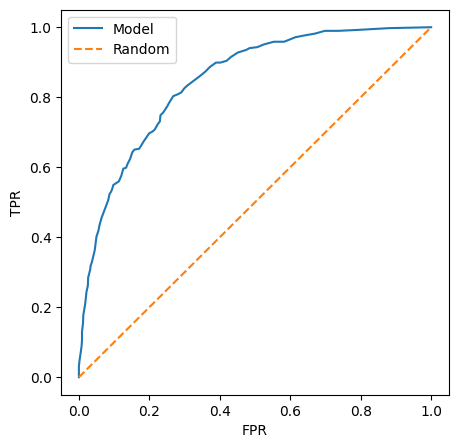

In [81]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()